Since My IBM Cognos Analytics Trial Period Expired, I did these tasks on jupyter notebook
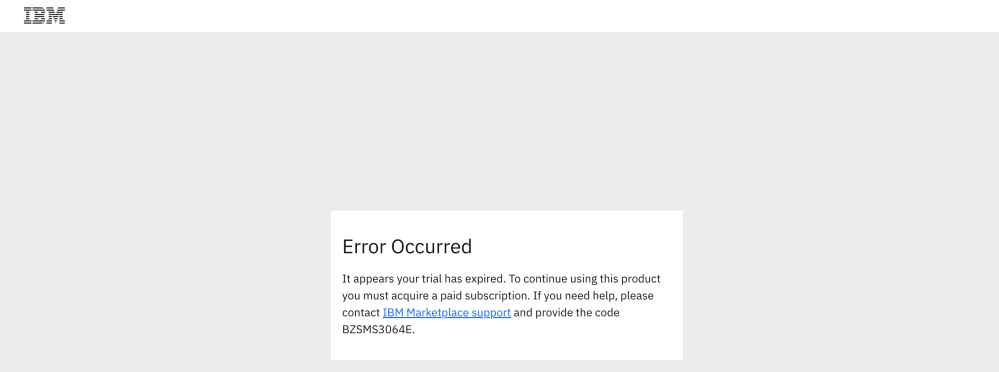

Import the pandas module.


In [1]:
import pandas as pd

Load the dataset into a dataframe.


In [2]:
# import requests
# import io

# response = requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m5_survey_data_technologies_normalised.csv")

# byte_data = response.content

# binary_stream_data = io.BytesIO(byte_data)

# df = pd.read_csv(binary_stream_data)

# df.to_csv('m5_survey_data_technologies_normalised.csv', index = False)

In [3]:
# reading data after uploading and saving them in local folder using requests library
df = pd.read_csv('m5_survey_data_technologies_normalised.csv')

df.head()

,Respondent,LanguageWorkedWith,LanguageDesireNextYear,DatabaseWorkedWith,DatabaseDesireNextYear,PlatformWorkedWith,PlatformDesireNextYear,WebFrameWorkedWith,WebFrameDesireNextYear,DevEnviron,OpSys,Containers,BlockchainOrg,BlockchainIs
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,C,C,MySQL,MySQL,Linux,Linux,NaN,NaN,Eclipse,NaN,NaN,NaN,NaN
2,4.0,C++,C#,SQLite,SQLite,Windows,Windows,NaN,NaN,Vim,NaN,NaN,NaN,NaN
3,4.0,C#,JavaScript,NaN,NaN,NaN,NaN,NaN,NaN,Visual Studio,NaN,NaN,NaN,NaN
4,4.0,Python,SQL,NaN,NaN,NaN,NaN,NaN,NaN,Visual Studio Code,NaN,NaN,NaN,NaN


### Prompt 2:
Does the GitHub link of view the dashboard you provided include the Current Technology Usage dashboard tab, which uses the data asset m5_survey_data_technologies_normalised.csv and captures the following metrics as visualizations?

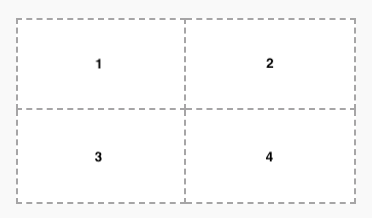

In the first rectangle (Panel 1):

Capture Top 10 LanguageWorkedWith.

Visualize as a Bar chart.

Utilize Bars, Length, Color fields of Bar chart.

Include Show value labels feature.

Include a proper Chart title.


In the second rectangle (Panel 2):

Capture Top 10 DatabaseWorkedWith.

Visualize as a Column chart.

Utilize Bars, Length, Color fields of Column chart.

Include Show value labels feature.

Include a proper Chart title.


In the third rectangle (Panel 3):

Capture PlatformWorkedWith.

Visualize as a Word cloud chart.

Utilize Words, Size, Color fields of Word cloud chart.

Include a proper Chart title.


In the fourth rectangle (Panel 4):

Capture Top 10 WebFrameWorkedWith.

Visualize as a Hierarchy bubble chart.

Utilize Bubbles, Size, Color fields of Hierarchy bubble chart.

Include a proper Chart title.

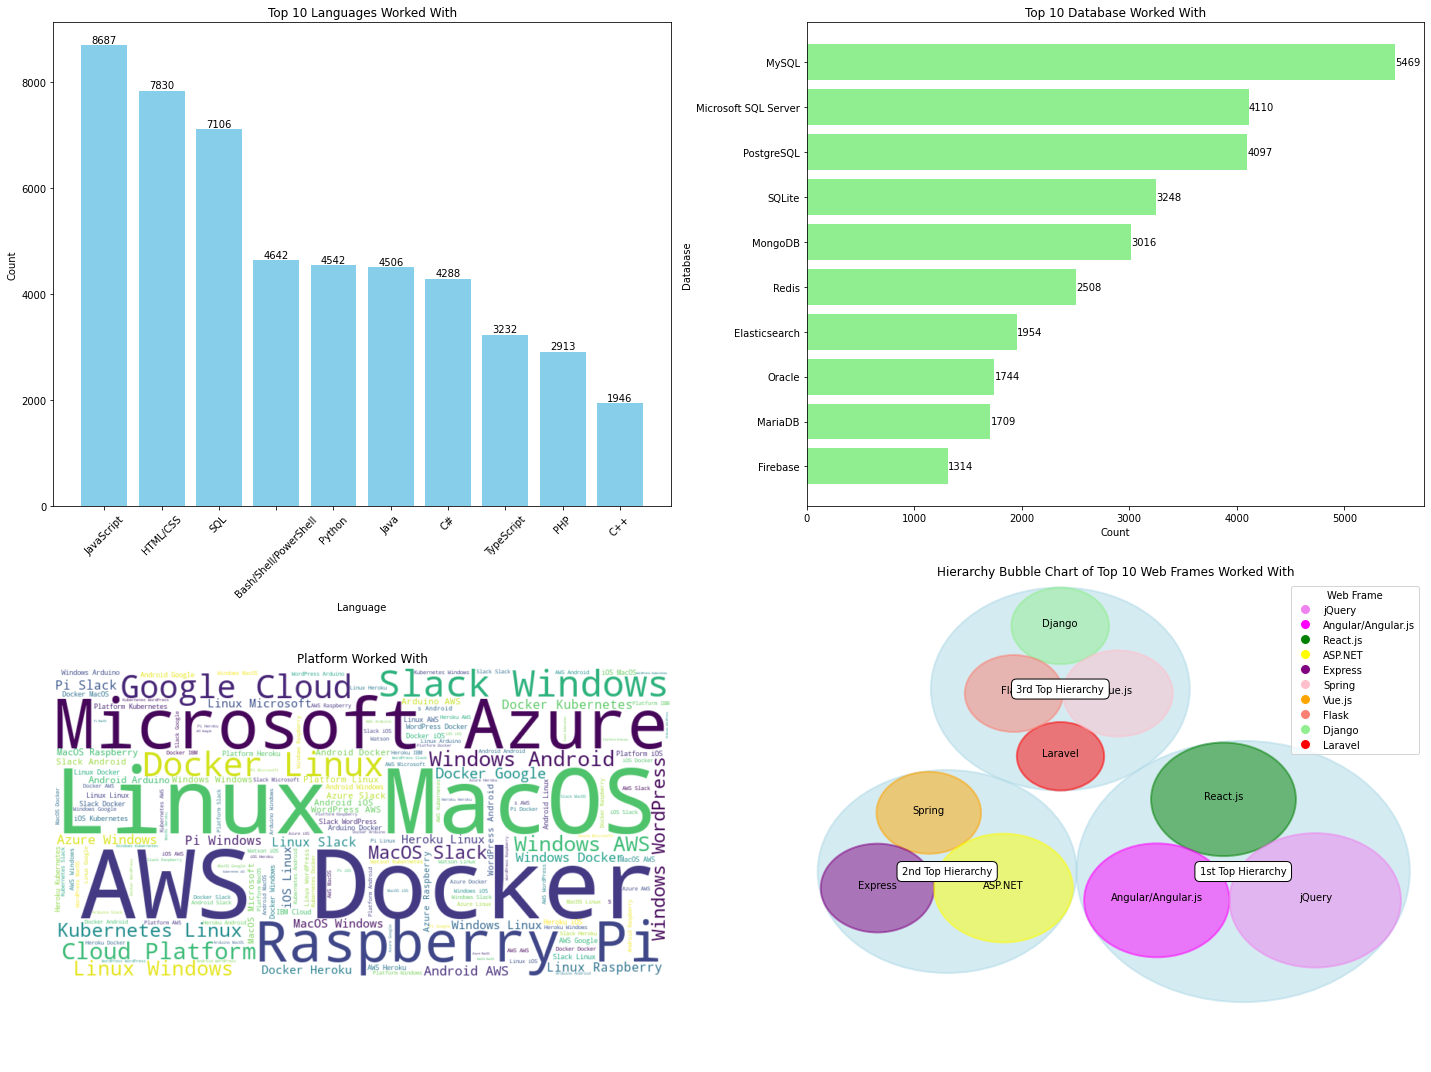

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load the data
df = pd.read_csv("m5_survey_data_technologies_normalised.csv")

# Set up the figure and axes for subplots
fig, axs = plt.subplots(2, 2, figsize=(20, 15))

# Panel 1: Top 10 LanguageWorkedWith (Bar chart)
top_10_languages = df['LanguageWorkedWith'].value_counts().head(10)
axs[0, 0].bar(top_10_languages.index, top_10_languages.values, color='skyblue')
axs[0, 0].set_title('Top 10 Languages Worked With')
axs[0, 0].set_xlabel('Language')
axs[0, 0].set_ylabel('Count')
axs[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(top_10_languages.values):
    axs[0, 0].text(i, v + 5, str(v), ha='center', va='bottom')

# Panel 2: Top 10 DatabaseWorkedWith (Column chart)
top_10_databases = df['DatabaseWorkedWith'].value_counts().head(10)
axs[0, 1].barh(top_10_databases.index, top_10_databases.values, color='lightgreen')
axs[0, 1].set_title('Top 10 Database Worked With')
axs[0, 1].set_xlabel('Count')
axs[0, 1].set_ylabel('Database')
axs[0, 1].invert_yaxis()
for i, v in enumerate(top_10_databases.values):
    axs[0, 1].text(v + 3, i, str(v), ha='left', va='center')

# Panel 3: PlatformWorkedWith (Word cloud)
platforms = ' '.join(df['PlatformWorkedWith'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(platforms)
axs[1, 0].imshow(wordcloud, interpolation='bilinear')
axs[1, 0].set_title('Platform Worked With')
axs[1, 0].axis('off')

# Panel 4: Top 10 WebFrameWorkedWith (Hierarchy bubble chart)
top_10_web_frames = df['WebFrameWorkedWith'].value_counts().head(10)

data = [{'id': 'Web Frame Work', 'datum' : top_10_web_frames[:].sum(), 'children' : [ \
              {'id' : "1st Top Hierarchy", 'datum': top_10_web_frames[:3].sum(),
                   'children' : [
                     {'id' : top_10_web_frames.index[0], 'datum' : top_10_web_frames[0]},
                     {'id' : top_10_web_frames.index[1], 'datum' : top_10_web_frames[1]},
                     {'id' : top_10_web_frames.index[2], 'datum' : top_10_web_frames[2]} 
                   ]},
              {'id' : "2nd Top Hierarchy", 'datum' : top_10_web_frames[3:6].sum(), 
                   'children' : [
                     {'id' : top_10_web_frames.index[3], 'datum' : top_10_web_frames[3]},
                     {'id' : top_10_web_frames.index[4], 'datum' : top_10_web_frames[4]},
                     {'id' : top_10_web_frames.index[5], 'datum' : top_10_web_frames[5]}
                   ]},
              {'id' : "3rd Top Hierarchy", 'datum' : top_10_web_frames[3:6].sum(),  
                   'children' : [
                     {'id' : top_10_web_frames.index[6], 'datum' : top_10_web_frames[6]},
                     {'id' : top_10_web_frames.index[7], 'datum' : top_10_web_frames[7]},
                     {'id' : top_10_web_frames.index[8], 'datum' : top_10_web_frames[8]},
                     {'id' : top_10_web_frames.index[9], 'datum' : top_10_web_frames[9]}
                   ]}
    ]}]



# import the circlify library
import circlify

# Compute circle positions thanks to the circlify() function
circles = circlify.circlify(
    data, 
    show_enclosure=False, 
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# import libraries
import circlify
import matplotlib.pyplot as plt

# Title
axs[1, 1].set_title('Hierarchy Bubble Chart of Top 10 Web Frames Worked With')

# Remove axes
axs[1, 1].axis('off')

# Find axis boundaries
lim = max(
    max(
        abs(circle.x) + circle.r,
        abs(circle.y) + circle.r,
    )
    for circle in circles
)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

# Define a color palette for the bubbles
colors = ['red', 'lightgreen', 'salmon', 'orange', 'pink', 'purple', 'yellow', 'green', 'magenta', 'violet']

# Print circle the highest level (web frames):
for circle in circles:
    if circle.level != 2:
        continue
    x, y, r = circle
    axs[1, 1].add_patch( plt.Circle((x, y), r, alpha=0.5, linewidth=2, color="lightblue"))

# Print circle and labels for the highest level:
for idx, circle in enumerate(circles):
    if circle.level != 3:
        continue
    x, y, r = circle
    label = circle.ex["id"]
    axs[1, 1].add_patch( plt.Circle((x, y), r, alpha=0.5, linewidth=2, color=colors[idx - 4])) # the first internal circle index start at 4 
    plt.annotate(label, (x,y ), ha='center', color="black")

# Print labels for the web frames
for circle in circles:
    if circle.level != 2:
        continue
    x, y, r = circle
    label = circle.ex["id"]
    plt.annotate(label, (x,y ) ,va='center', ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round', pad=.5))






# Create custom legend with handles for each web framework
handles = [plt.Line2D([], [], marker='o', markersize=10, color='white', markerfacecolor=color) for color in reversed(colors)]
labels = top_10_web_frames.index

# Add labels to legend
axs[1, 1].legend(handles, labels, loc='upper right', title='Web Frame')

plt.tight_layout()
plt.show()


### Prompt 3:
Does the GitHub link view the dashboard you provided include the Future Technology Trend dashboard tab, which uses the data asset m5_survey_data_technologies_normalised.csv and captures the following metrics as visualizations?

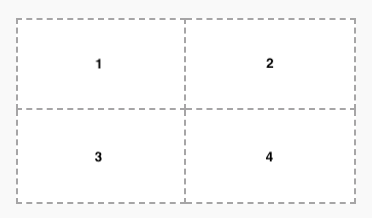

In the first rectangle (Panel 1):

Capture Top 10 LanguageDesireNextYear.

Visualize as a Bar chart.

Utilize Bars, Length, Color fields of Bar chart.

Include Show value labels feature.

Include a proper Chart title.

In the second rectangle (Panel 2):

Capture Top 10 DatabaseDesireNextYear.

Visualize as a Column chart.

Utilize Bars, Length, Color fields of Column chart.

Include Show value labels feature.

Include a proper Chart title.

In the third rectangle (Panel 3):

capture PlatformDesireNextYear.

Visualize as a Tree map chart.

Utilize Area hierarchy, Size, Heat fields of Tree map chart.

Include Contrast label color feature.

Include a proper Chart title.

In the fourth rectangle (Panel 4):

Capture Top 10 WebFrameDesireNextYear.

Visualize as a Hierarchy bubble chart.

Utilize Bubbles, Size, Color fields of Hierarchy bubble chart.

Include a proper Chart title.

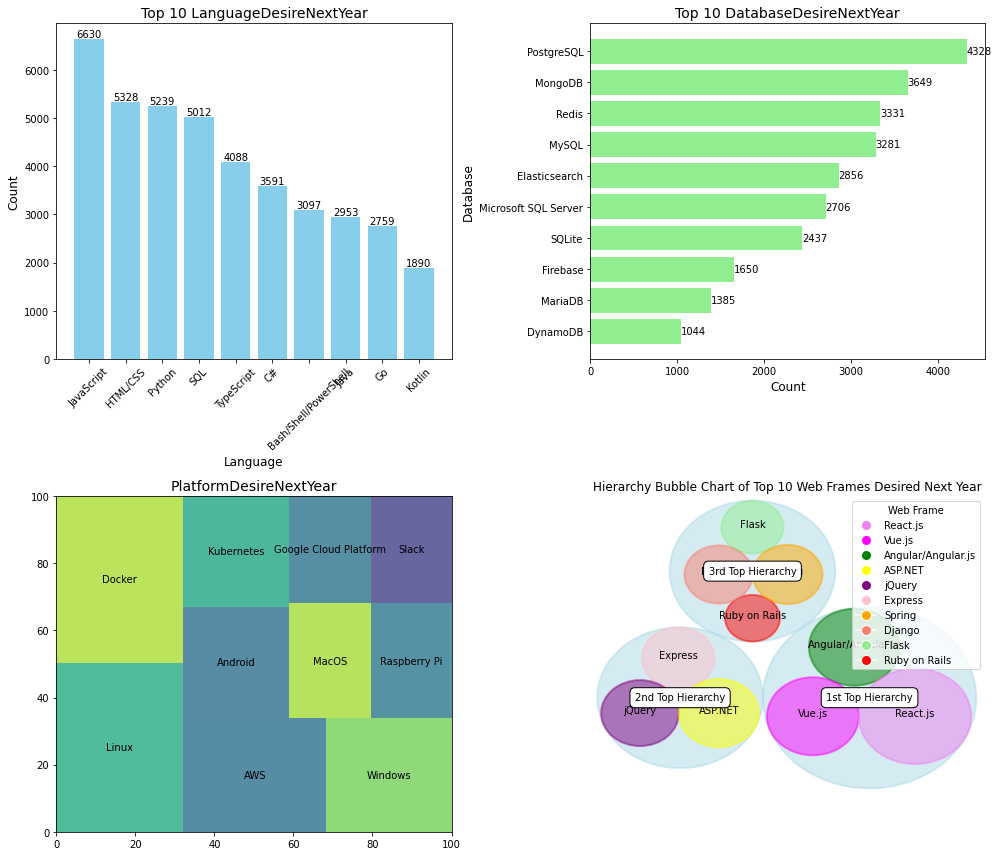

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

# Load the data
df = pd.read_csv('m5_survey_data_technologies_normalised.csv')

# Create subplots with adjusted size
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Top 10 LanguageDesireNextYear (Bar chart)
top_10_languages = df['LanguageDesireNextYear'].value_counts().head(10)
axs[0, 0].bar(top_10_languages.index, top_10_languages.values, color='skyblue')
axs[0, 0].set_title('Top 10 LanguageDesireNextYear', fontsize=14)
axs[0, 0].set_xlabel('Language', fontsize=12)
axs[0, 0].set_ylabel('Count', fontsize=12)
axs[0, 0].tick_params(axis='x', rotation=45, labelsize=10)
axs[0, 0].tick_params(axis='y', labelsize=10)
for i, v in enumerate(top_10_languages.values):
    axs[0, 0].text(i, v, str(v), ha='center', va='bottom', fontsize=10)

# Panel 2: Top 10 DatabaseDesireNextYear (Column chart)
top_10_databases = df['DatabaseDesireNextYear'].value_counts().head(10)
axs[0, 1].barh(top_10_databases.index, top_10_databases.values, color='lightgreen')
axs[0, 1].set_title('Top 10 DatabaseDesireNextYear', fontsize=14)
axs[0, 1].set_xlabel('Count', fontsize=12)
axs[0, 1].set_ylabel('Database', fontsize=12)
axs[0, 1].invert_yaxis()
axs[0, 1].tick_params(axis='x', labelsize=10)
axs[0, 1].tick_params(axis='y', labelsize=10)
for i, v in enumerate(top_10_databases.values):
    axs[0, 1].text(v, i, str(v), ha='left', va='center', fontsize=10)

# Panel 3: PlatformDesireNextYear (Tree map chart)
platform_desire = df['PlatformDesireNextYear'].value_counts().head(10)
squarify.plot(sizes=platform_desire.values, label=platform_desire.index, ax=axs[1, 0], alpha=0.8, text_kwargs={'fontsize': 10})
axs[1, 0].set_title('PlatformDesireNextYear', fontsize=14)

# Panel 4: Top 10 WebFrameDesireNextYear (Hierarchy bubble chart)
top_10_web_frames = df['WebFrameDesireNextYear'].value_counts().head(10)

data = [{'id': 'Web Frame Work', 'datum' : top_10_web_frames[:].sum(), 'children' : [ \
              {'id' : "1st Top Hierarchy", 'datum': top_10_web_frames[:3].sum(),
                   'children' : [
                     {'id' : top_10_web_frames.index[0], 'datum' : top_10_web_frames[0]},
                     {'id' : top_10_web_frames.index[1], 'datum' : top_10_web_frames[1]},
                     {'id' : top_10_web_frames.index[2], 'datum' : top_10_web_frames[2]} 
                   ]},
              {'id' : "2nd Top Hierarchy", 'datum' : top_10_web_frames[3:6].sum(), 
                   'children' : [
                     {'id' : top_10_web_frames.index[3], 'datum' : top_10_web_frames[3]},
                     {'id' : top_10_web_frames.index[4], 'datum' : top_10_web_frames[4]},
                     {'id' : top_10_web_frames.index[5], 'datum' : top_10_web_frames[5]}
                   ]},
              {'id' : "3rd Top Hierarchy", 'datum' : top_10_web_frames[3:6].sum(),  
                   'children' : [
                     {'id' : top_10_web_frames.index[6], 'datum' : top_10_web_frames[6]},
                     {'id' : top_10_web_frames.index[7], 'datum' : top_10_web_frames[7]},
                     {'id' : top_10_web_frames.index[8], 'datum' : top_10_web_frames[8]},
                     {'id' : top_10_web_frames.index[9], 'datum' : top_10_web_frames[9]}
                   ]}
    ]}]



# import the circlify library
import circlify

# Compute circle positions thanks to the circlify() function
circles = circlify.circlify(
    data, 
    show_enclosure=False, 
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)

# import libraries
import circlify
import matplotlib.pyplot as plt

# Title
axs[1, 1].set_title('Hierarchy Bubble Chart of Top 10 Web Frames Desired Next Year')

# Remove axes
axs[1, 1].axis('off')

# Find axis boundaries
lim = max(
    max(
        abs(circle.x) + circle.r,
        abs(circle.y) + circle.r,
    )
    for circle in circles
)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

# Define a color palette for the bubbles
colors = ['red', 'lightgreen', 'salmon', 'orange', 'pink', 'purple', 'yellow', 'green', 'magenta', 'violet']

# Print circle the highest level (web frames):
for circle in circles:
    if circle.level != 2:
        continue
    x, y, r = circle
    axs[1, 1].add_patch( plt.Circle((x, y), r, alpha=0.5, linewidth=2, color="lightblue"))

# Print circle and labels for the highest level:
for idx, circle in enumerate(circles):
    if circle.level != 3:
        continue
    x, y, r = circle
    label = circle.ex["id"]
    axs[1, 1].add_patch( plt.Circle((x, y), r, alpha=0.5, linewidth=2, color=colors[idx - 4])) # the first internal circle index start at 4 
    plt.annotate(label, (x,y ), ha='center', color="black")

# Print labels for the web frames
for circle in circles:
    if circle.level != 2:
        continue
    x, y, r = circle
    label = circle.ex["id"]
    plt.annotate(label, (x,y ) ,va='center', ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round', pad=.5))

# Create custom legend with handles for each web framework
handles = [plt.Line2D([], [], marker='o', markersize=10, color='white', markerfacecolor=color) for color in reversed(colors)]
labels = top_10_web_frames.index

# Add labels to legend
axs[1, 1].legend(handles, labels, loc='upper right', title='Web Frame')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()


### Prompt 4:
Does the GitHub link view the dashboard you provided include the Demographics dashboard tab, which uses the data asset m5_survey_data_demographics.csv and captures the following metrics as visualizations?

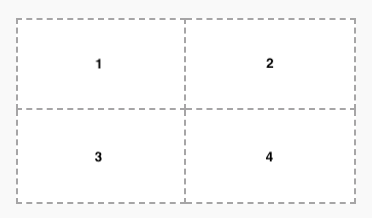

Use Filters for this tab feature to filter out entries of other types except Man and Woman from the data point Gender.


In the first rectangle (Panel 1):

Capture Respondent classified by Gender.

Visualize as a Pie chart.

Utilize Segments, Size fields of Pie chart.

Include Dispay % feature.

Include a proper Chart title.

In the second rectangle (Panel 2):

Capture Respondent Count for Countries.

Visualize as a Map chart.

Utilize Regions-Locations, Regions-Location color fields of Map chart.

Include a proper Chart title.

In the third rectangle (Panel 3):

Capture Respondent Count by Age.

Visualize as a Line chart.

Utilize x-axis, y-axis fields of Line chart.

Include Show value labels feature.

Include Show markers feature.

Include a proper Chart title.

In the fourth rectangle (Panel 4):

Capture Respondent Count by Gender, classified by Formal Education Level.

Visualize as a Stacked bar chart.

Utilize Bars, Length, Color fields of Stacked bar chart.

Include Show value labels feature.

Include a proper Chart title.

In [13]:
# import requests
# import io

# response = requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m5_survey_data_demographics.csv")

# byte_data = response.content

# binary_stream_data = io.BytesIO(byte_data)

# df = pd.read_csv(binary_stream_data)

# df.to_csv('m5_survey_data_demographics.csv', index = False)

In [62]:
# reading data after uploading and saving them in local folder using requests library
df = pd.read_csv('m5_survey_data_demographics.csv')

df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


/var/folders/4r/s0lkrrt51f37rcn2cbnn_5gr0000gn/T/ipykernel_817/2695513712.py:41: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


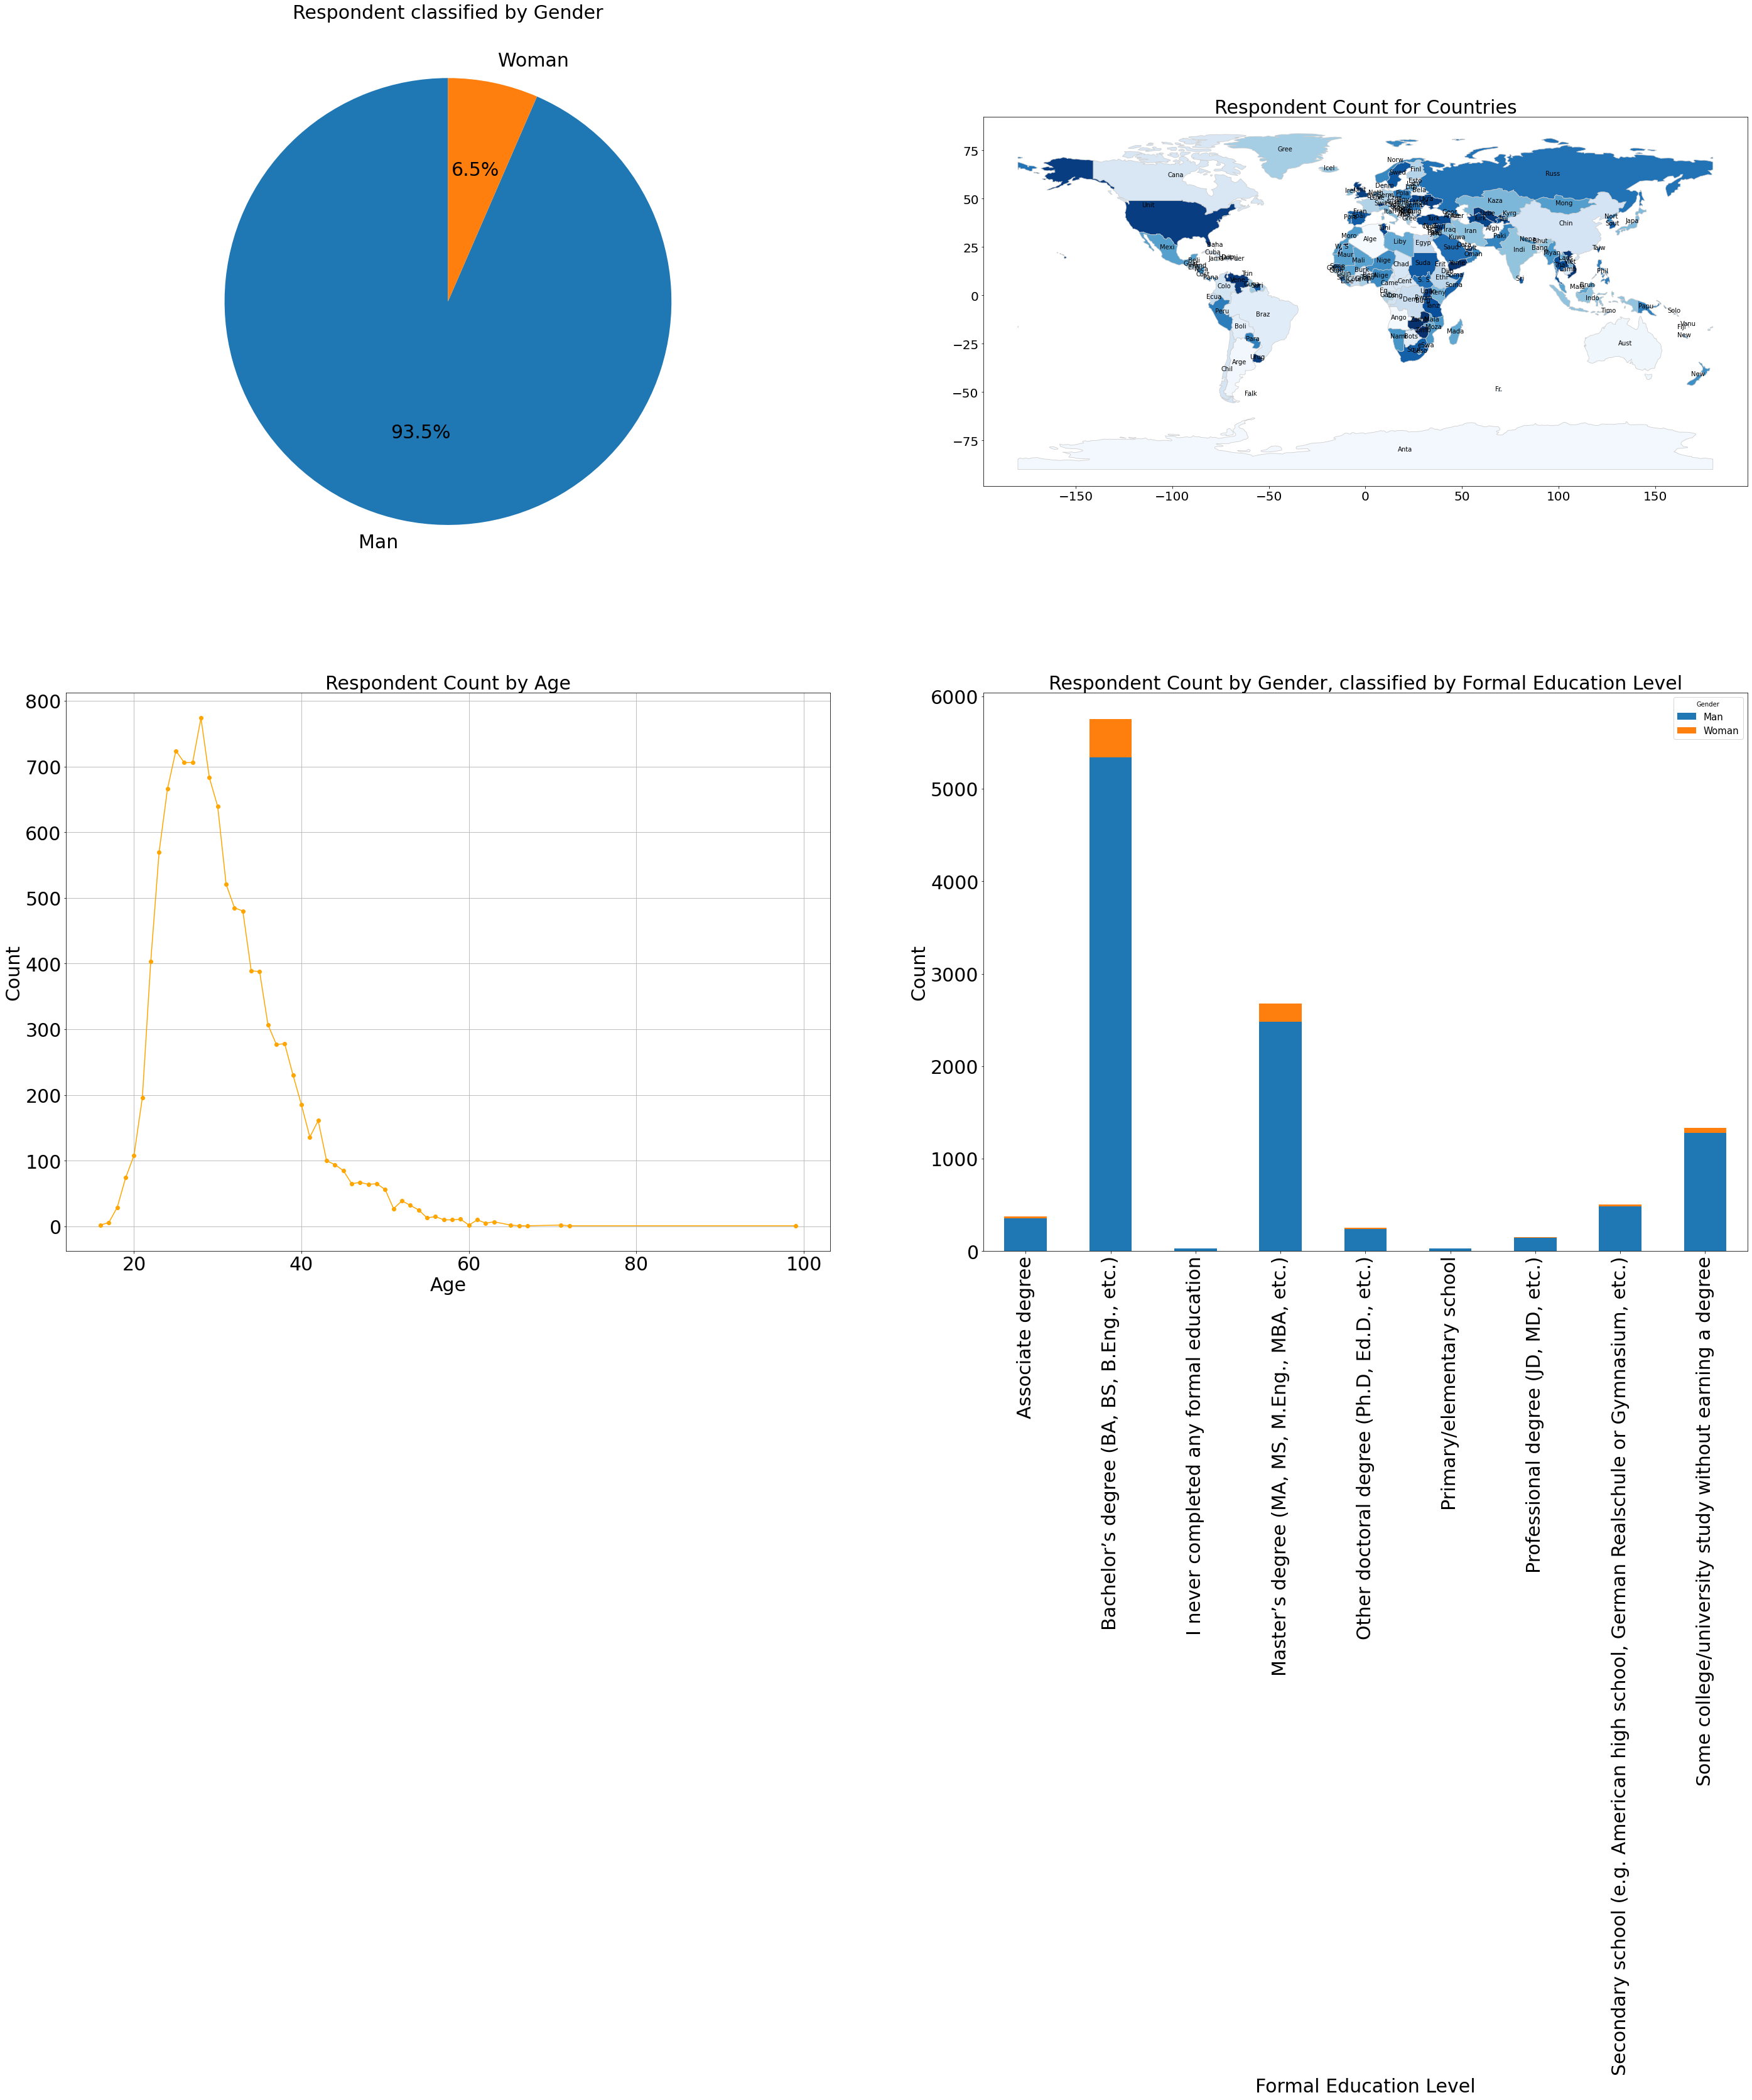

<Figure size 432x288 with 0 Axes>

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('m5_survey_data_demographics.csv')

# Filter data for Man and Woman
df_filtered = df[df['Gender'].isin(['Man', 'Woman'])]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(48, 36))

# Panel 1: Respondent classified by Gender (Pie chart)
gender_counts = df_filtered['Gender'].value_counts()
axs[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 30})  # Increase font size
axs[0, 0].set_title('Respondent classified by Gender', fontsize=30)

# Panel 3: Respondent Count by Age (Line chart)
age_counts = df_filtered['Age'].value_counts().sort_index()
axs[1, 0].plot(age_counts.index, age_counts.values, marker='o', color='orange')
axs[1, 0].set_title('Respondent Count by Age', fontsize=30)
axs[1, 0].set_xlabel('Age', fontsize=30)
axs[1, 0].set_ylabel('Count', fontsize=30)
axs[1, 0].grid(True)
axs[1, 0].tick_params(axis='both', which='both', labelsize=30)  # Increase font size of grid marker text

# Panel 4: Respondent Count by Gender, classified by Formal Education Level (Stacked bar chart)
education_counts = df_filtered.groupby(['EdLevel', 'Gender']).size().unstack(fill_value=0)
education_counts.plot(kind='bar', stacked=True, ax=axs[1, 1])
axs[1, 1].set_title('Respondent Count by Gender, classified by Formal Education Level', fontsize=30)
axs[1, 1].set_xlabel('Formal Education Level', fontsize=30)
axs[1, 1].set_ylabel('Count', fontsize=30)
axs[1, 1].tick_params(axis='both', which='both', labelsize=30)  # Increase font size of grid marker text
axs[1, 1].legend(title='Gender', fontsize=15)

# Panel 2: Respondent Count for Countries (Map chart)
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the world map shapefile
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

country_counts = df_filtered['Country'].value_counts()

# Merge country counts with world map
world = world.merge(country_counts, how='left', left_on='name', right_index=True)

world.plot(column='name', cmap='Blues', linewidth=0.8, ax=axs[0, 1], edgecolor='0.8', legend=False)

# Annotate country names
for idx, row in world.iterrows():
    axs[0, 1].annotate(text=row['name'][:4], xy=(row.geometry.centroid.x, row.geometry.centroid.y), ha='center', fontsize=10)

axs[0, 1].set_title('Respondent Count for Countries', fontsize=30)
axs[0, 1].tick_params(axis='both', which='both', labelsize=20)  # Increase font size of grid marker text

plt.show()




# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()
